In [71]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV


In [72]:
cleanData = pd.read_csv("Melbourne_Cleaned_Encoded.csv")
cleanData
cleanData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Columns: 431 entries, Rooms to Agents_others
dtypes: bool(416), float64(11), int64(4)
memory usage: 17.8 MB


In [73]:
cleanData.describe()


,Rooms,Price,Distance,Postcode,BedroomNo,BathroomNo,CarNo,Landsize,BuildingArea,YearBuilt,Latitude,Longtitude,Propertycount,SalesYear,SalesMonth
count,34857.000000,3.485700e+04,34857.000000,34856.000000,34857.000000,34857.000000,34857.000000,34857.000000,34857.000000,34857.000000,34857.00000,34857.000000,34857.000000,34857.000000,34857.000000
mean,3.031012,1.010838e+06,11.184904,3116.062859,3.064693,1.713343,1.796741,569.001520,145.562827,1967.898643,-37.80994,145.003212,7572.818602,2016.839946,7.141951
std,0.969933,5.719992e+05,6.788797,109.023903,0.858090,0.652754,0.882969,2763.907731,252.222644,25.042048,0.07929,0.105558,4427.906124,0.636292,3.158799
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.19043,144.423790,83.000000,2016.000000,1.000000
25%,2.000000,6.950000e+05,6.400000,3051.000000,3.000000,1.000000,1.000000,357.000000,136.000000,1970.000000,-37.84690,144.964400,4385.000000,2016.000000,5.000000
50%,3.000000,8.700000e+05,10.300000,3103.000000,3.000000,2.000000,2.000000,521.000000,136.000000,1970.000000,-37.80760,145.007800,6763.000000,2017.000000,7.000000
75%,4.000000,1.150000e+06,14.000000,3156.000000,3.000000,2.000000,2.000000,598.000000,136.000000,1970.000000,-37.77090,145.051750,10412.000000,2017.000000,10.000000
max,16.000000,1.120000e+07,48.100000,3978.000000,30.000000,12.000000,26.000000,433014.000000,44515.000000,2106.000000,-37.39020,145.526350,21650.000000,2018.000000,12.000000


In [74]:
# show number of unique values in each column
for column in cleanData.columns:
    unique_count = cleanData[column].nunique()
    print(f"'{column}': {unique_count}")

'Rooms': 12
'Price': 2871
'Distance': 215
'Postcode': 211
'BedroomNo': 15
'BathroomNo': 11
'CarNo': 15
'Landsize': 1684
'BuildingArea': 740
'YearBuilt': 160
'Latitude': 13402
'Longtitude': 14524
'Propertycount': 342
'SalesYear': 3
'SalesMonth': 12
'CouncilArea_Bayside City Council': 2
'CouncilArea_Boroondara City Council': 2
'CouncilArea_Brimbank City Council': 2
'CouncilArea_Cardinia Shire Council': 2
'CouncilArea_Casey City Council': 2
'CouncilArea_Darebin City Council': 2
'CouncilArea_Frankston City Council': 2
'CouncilArea_Glen Eira City Council': 2
'CouncilArea_Greater Dandenong City Council': 2
'CouncilArea_Hobsons Bay City Council': 2
'CouncilArea_Hume City Council': 2
'CouncilArea_Kingston City Council': 2
'CouncilArea_Knox City Council': 2
'CouncilArea_Macedon Ranges Shire Council': 2
'CouncilArea_Manningham City Council': 2
'CouncilArea_Maribyrnong City Council': 2
'CouncilArea_Maroondah City Council': 2
'CouncilArea_Melbourne City Council': 2
'CouncilArea_Melton City Council

In [75]:
cleanData.head(15)

,Rooms,Price,Distance,Postcode,BedroomNo,BathroomNo,CarNo,Landsize,BuildingArea,YearBuilt,...,Agents_Jellis,Agents_Marshall,Agents_McGrath,Agents_Nelson,Agents_Noel,Agents_RT,Agents_Ray,Agents_Woodards,Agents_hockingstuart,Agents_others
0,2,870000.0,2.5,3067.0,2.0,1.0,1.0,126.0,136.0,1970.0,...,True,False,False,False,False,False,False,False,False,False
1,2,1480000.0,2.5,3067.0,2.0,1.0,1.0,202.0,136.0,1970.0,...,False,False,False,False,False,False,False,False,False,False
2,2,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,...,False,False,False,False,False,False,False,False,False,False
3,3,870000.0,2.5,3067.0,3.0,2.0,1.0,0.0,136.0,1970.0,...,False,False,False,False,False,False,False,False,False,True
4,3,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,...,False,False,False,False,False,False,False,False,False,False
5,3,850000.0,2.5,3067.0,3.0,2.0,1.0,94.0,136.0,1970.0,...,False,False,False,False,False,False,False,False,False,False
6,4,1600000.0,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,...,False,False,False,True,False,False,False,False,False,False
7,4,870000.0,2.5,3067.0,3.0,2.0,2.0,400.0,220.0,2006.0,...,False,False,False,True,False,False,False,False,False,False
8,2,870000.0,2.5,3067.0,4.0,1.0,2.0,201.0,136.0,1900.0,...,False,False,False,False,False,False,False,False,False,False
9,2,870000.0,2.5,3067.0,3.0,2.0,1.0,202.0,136.0,1900.0,...,False,False,False,False,False,False,False,False,False,True


In [76]:
cleanData.tail(15)

,Rooms,Price,Distance,Postcode,BedroomNo,BathroomNo,CarNo,Landsize,BuildingArea,YearBuilt,...,Agents_Jellis,Agents_Marshall,Agents_McGrath,Agents_Nelson,Agents_Noel,Agents_RT,Agents_Ray,Agents_Woodards,Agents_hockingstuart,Agents_others
34842,3,1400000.0,6.8,3016.0,3.0,2.0,2.0,325.0,158.0,1995.0,...,False,False,False,False,False,False,False,False,False,True
34843,3,830000.0,6.8,3016.0,3.0,1.0,2.0,345.0,136.0,1949.0,...,False,False,False,False,False,False,False,False,True,False
34844,1,440000.0,4.6,3181.0,3.0,2.0,2.0,521.0,136.0,1970.0,...,False,False,False,False,False,False,False,False,False,False
34845,4,870000.0,4.6,3181.0,4.0,3.0,2.0,279.0,237.0,2009.0,...,True,False,False,False,False,False,False,False,False,False
34846,4,630000.0,25.5,3750.0,4.0,2.0,2.0,388.0,136.0,1970.0,...,False,False,False,False,False,False,False,False,True,False
34847,3,500000.0,25.5,3750.0,3.0,2.0,2.0,383.0,118.0,2016.0,...,False,False,False,False,False,False,True,False,False,False
34848,4,621000.0,25.5,3750.0,4.0,2.0,2.0,375.0,136.0,1970.0,...,False,False,False,False,False,False,False,False,True,False
34849,3,570000.0,25.5,3750.0,3.0,2.0,2.0,404.0,158.0,2012.0,...,False,False,False,False,False,False,False,False,False,True
34850,3,870000.0,25.5,3750.0,3.0,2.0,2.0,268.0,135.0,2016.0,...,False,False,False,False,False,False,False,False,False,True
34851,3,1101000.0,6.3,3013.0,3.0,1.0,2.0,288.0,136.0,1970.0,...,False,False,False,False,False,False,False,False,False,True


In [77]:
CorrelationMatrix = cleanData.corr()


In [78]:
CorrelationMatrix

,Rooms,Price,Distance,Postcode,BedroomNo,BathroomNo,CarNo,Landsize,BuildingArea,YearBuilt,...,Agents_Jellis,Agents_Marshall,Agents_McGrath,Agents_Nelson,Agents_Noel,Agents_RT,Agents_Ray,Agents_Woodards,Agents_hockingstuart,Agents_others
Rooms,1.000000,0.391636,0.271511,0.085890,0.823813,0.481545,0.317095,0.031214,0.102947,-0.015319,...,-0.004227,0.076102,-0.028532,-0.042131,0.019142,0.015920,0.039066,-0.030517,-0.067651,-0.021214
Price,0.391636,1.000000,-0.181799,0.035048,0.320101,0.278823,0.137131,0.027306,0.065188,-0.195416,...,0.126504,0.224048,-0.004315,-0.007595,0.027341,0.066012,-0.068323,0.002237,-0.044213,-0.128929
Distance,0.271511,-0.181799,1.000000,0.481566,0.239957,0.102236,0.204163,0.048273,0.051006,0.220190,...,-0.160450,-0.140478,-0.004091,-0.179242,0.022849,-0.060682,0.143284,-0.029056,-0.011148,0.150175
Postcode,0.085890,0.035048,0.481566,1.000000,0.080764,0.102334,0.058617,0.032185,0.029902,0.062361,...,-0.018786,0.070611,0.006294,-0.173170,0.011659,0.005486,0.045101,0.014675,0.033595,0.035622
BedroomNo,0.823813,0.320101,0.239957,0.080764,1.000000,0.585415,0.375109,0.034713,0.112591,-0.004083,...,-0.007059,0.062268,-0.016667,-0.044164,0.016239,0.010691,0.037804,-0.024829,-0.059275,-0.010245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Agents_RT,0.015920,0.066012,-0.060682,0.005486,0.010691,0.038182,0.015842,0.002995,0.003962,-0.011922,...,-0.040030,-0.030459,-0.016250,-0.039213,-0.015144,1.000000,-0.029840,-0.017726,-0.034967,-0.084481
Agents_Ray,0.039066,-0.068323,0.143284,0.045101,0.037804,0.016826,0.030306,0.002106,-0.000810,0.064341,...,-0.079494,-0.060487,-0.032271,-0.077873,-0.030073,-0.029840,1.000000,-0.035202,-0.069441,-0.167771
Agents_Woodards,-0.030517,0.002237,-0.029056,0.014675,-0.024829,-0.028958,-0.010293,-0.002834,0.000601,-0.012679,...,-0.047224,-0.035933,-0.019171,-0.046261,-0.017865,-0.017726,-0.035202,1.000000,-0.041252,-0.099665
Agents_hockingstuart,-0.067651,-0.044213,-0.011148,0.033595,-0.059275,-0.029173,-0.024985,-0.004111,-0.007334,0.018001,...,-0.093155,-0.070882,-0.037816,-0.091255,-0.035241,-0.034967,-0.069441,-0.041252,1.000000,-0.196601


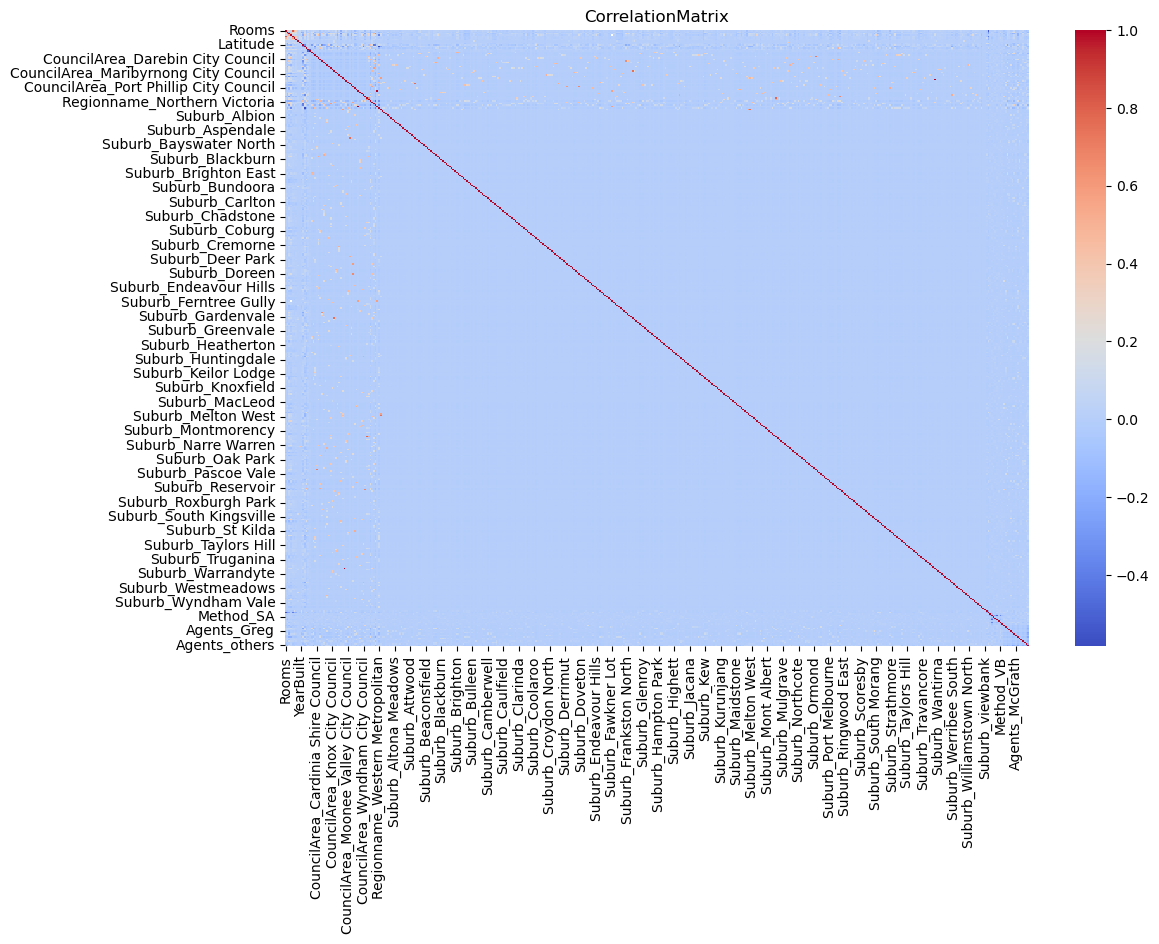

In [79]:
plt.figure(figsize=(12,8))
sns.heatmap(CorrelationMatrix, annot=False, cmap="coolwarm")
plt.title("CorrelationMatrix")
plt.show()

In [80]:
TargetColumn = "Price"
Target = cleanData[TargetColumn]
FeaturesData = cleanData.drop(columns=[TargetColumn])


In [81]:
FeaturesData.head()

,Rooms,Distance,Postcode,BedroomNo,BathroomNo,CarNo,Landsize,BuildingArea,YearBuilt,Latitude,...,Agents_Jellis,Agents_Marshall,Agents_McGrath,Agents_Nelson,Agents_Noel,Agents_RT,Agents_Ray,Agents_Woodards,Agents_hockingstuart,Agents_others
0,2,2.5,3067.0,2.0,1.0,1.0,126.0,136.0,1970.0,-37.8014,...,True,False,False,False,False,False,False,False,False,False
1,2,2.5,3067.0,2.0,1.0,1.0,202.0,136.0,1970.0,-37.7996,...,False,False,False,False,False,False,False,False,False,False
2,2,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,-37.8079,...,False,False,False,False,False,False,False,False,False,False
3,3,2.5,3067.0,3.0,2.0,1.0,0.0,136.0,1970.0,-37.8114,...,False,False,False,False,False,False,False,False,False,True
4,3,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,-37.8093,...,False,False,False,False,False,False,False,False,False,False


In [82]:
XTrain, XTest, YTrain, YTest = train_test_split(FeaturesData, Target, test_size=0.2, random_state=42)

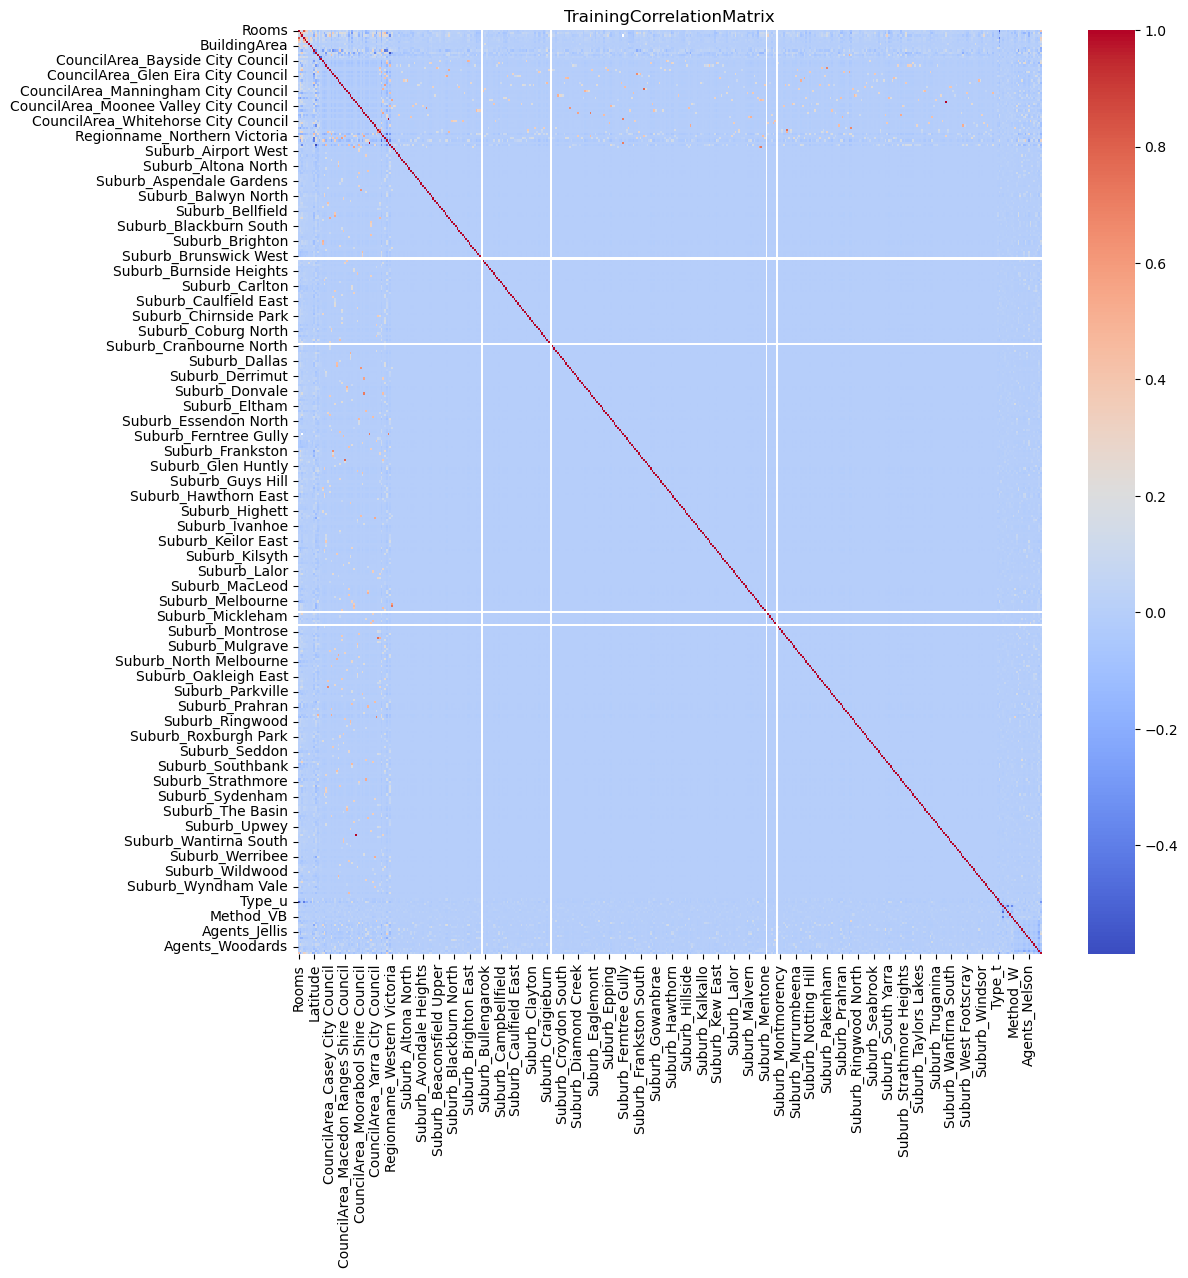

In [83]:
TrainingData = XTrain.copy()
TrainingData[TargetColumn] = YTrain

CorrelationMatrix = TrainingData.corr()

plt.figure(figsize=(12, 12))
sns.heatmap(CorrelationMatrix, annot=False, cmap="coolwarm")
plt.title("TrainingCorrelationMatrix")
plt.show()

Text(0, 0.5, 'Frequency')

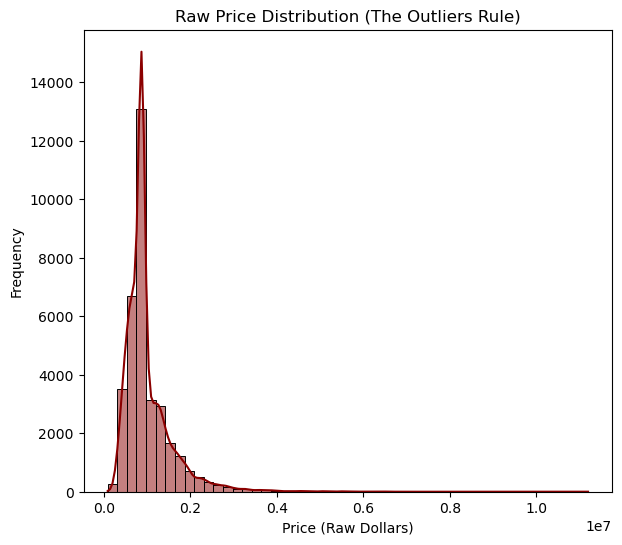

In [84]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(Target, kde=True, color="darkred", bins=50)
plt.title("Raw Price Distribution (The Outliers Rule)")
plt.xlabel("Price (Raw Dollars)")
plt.ylabel("Frequency")

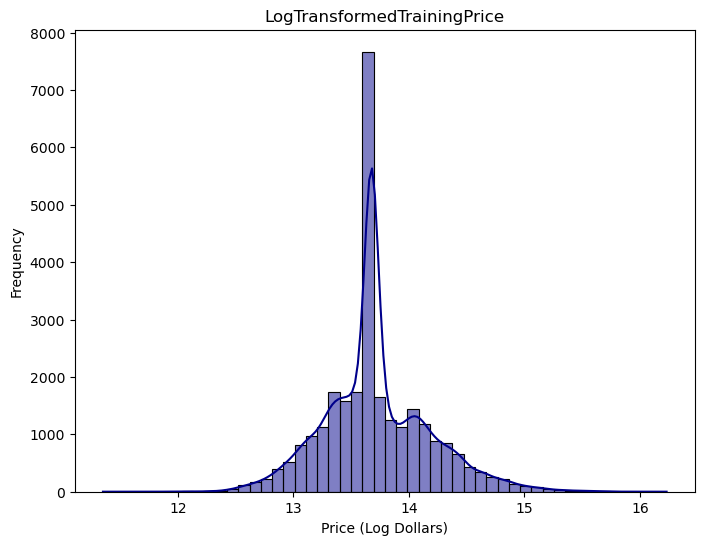

In [85]:
YTrainLog = np.log1p(YTrain)
YTestLog = np.log1p(YTest)

plt.figure(figsize=(8, 6))
sns.histplot(YTrainLog, kde=True, color="darkblue", bins=50)
plt.title("LogTransformedTrainingPrice")
plt.xlabel("Price (Log Dollars)")
plt.ylabel("Frequency")
plt.show()

In [86]:
Model1 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)


Model1.fit(XTrain, YTrainLog)

LogPredictions = Model1.predict(XTest)

RealPredictions = np.expm1(LogPredictions)
RealYTest = np.expm1(YTestLog)

MAE = mean_absolute_error(RealYTest, RealPredictions)
RMSE = np.sqrt(mean_squared_error(RealYTest, RealPredictions))
R2 = r2_score(RealYTest, RealPredictions)


print("-" * 30)
print("Model Evaluation Metrics:")
print("-" * 30)
print(f"Mean Absolute Error (MAE): ${MAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${RMSE:,.2f}")
print(f"R-squared Score (R2): {R2:.4f}")

------------------------------
Model Evaluation Metrics:
------------------------------
Mean Absolute Error (MAE): $213,374.55
Root Mean Squared Error (RMSE): $379,634.32
R-squared Score (R2): 0.5202


In [ ]:
parameterGrid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

Model2Tuned = RandomForestRegressor(random_state=42, n_jobs=-1)

RandomSearch = RandomizedSearchCV(
    estimator=Model2Tuned,
    param_distributions=parameterGrid,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

RandomSearch.fit(XTrain, YTrainLog)

print("-" * 30)
print(f"The Optimal Parameters: {RandomSearch.best_params_}")
print("-" * 30)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=14.5min
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time=17.1min
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time=17.1min
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time=17.8min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=12.9min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=12.5min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=12.6min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=13.7min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=12.8min
[CV] END max_depth